# Group-Level comparison of Epoch-Based Decoding Performance

This script aggregates  decoding curves of P300 workflow variants.




In [182]:
import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [183]:
def load_decoding_results(npz_path):
    with np.load(npz_path) as data:
        epoch_bins_loaded = data['epoch_bins']
        mean_acc = data['mean_accuracies']
        se_acc = data['se_accuracies']
    return epoch_bins_loaded, mean_acc, se_acc


In [184]:
manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript'
m_ica_dir = join(manuscript_dir, 'data', 'decoding', 'ica')
m_noica_dir = join(manuscript_dir, 'data', 'decoding','noica')
fig_dir = join(manuscript_dir, 'figures')

epoch_bins = np.linspace(5, 80, 16, dtype=int)
task = 'covert'


# Full paths
# Data1 => with rejections
# Data2 => without rejections
data1_path = os.path.join(m_ica_dir, f"{task}_lda_p300_decC_64_ica.npz")
data2_path = os.path.join(m_noica_dir, f"{task}_lda_p300_decC_64_noica.npz" )
data3_path = os.path.join(m_ica_dir, f"{task}_lda_alphaCSP_decC_64_ica.npz")
data4_path = os.path.join(m_noica_dir, f"{task}_lda_alphaCSP_decC_64_noica.npz" )
data5_path = os.path.join(m_ica_dir, f"{task}_lda_cvep_decC_64_ica.npz" )
data6_path = os.path.join(m_noica_dir, f"{task}_lda_cvep_decC_64_noica.npz" )
data7_path = os.path.join(m_ica_dir, f"{task}_lda_alphaSUBSET_decC_64_nativespace.npz")
data8_path = os.path.join(m_noica_dir, f"{task}_lda_alphaSUBSET_decC_64_noica.npz" )

# --...---...---...---...---...---...---...---...---...---...---...---...---...-
epoch_bins1, mean_acc1, se_acc1 = load_decoding_results(data1_path)
epoch_bins2, mean_acc2, se_acc2 = load_decoding_results(data2_path)
epoch_bins3, mean_acc3, se_acc3 = load_decoding_results(data3_path)
epoch_bins4, mean_acc4, se_acc4 = load_decoding_results(data4_path)
epoch_bins5, mean_acc5, se_acc5 = load_decoding_results(data5_path)
epoch_bins6, mean_acc6, se_acc6 = load_decoding_results(data6_path)
epoch_bins7, mean_acc7, se_acc7 = load_decoding_results(data7_path)
epoch_bins8, mean_acc8, se_acc8 = load_decoding_results(data8_path)
# --...---...---...---...---...---...---...---...---...---...---...---...---...-
data = {
    'P300 w/ ICA': {
        'mean': mean_acc1,
        'se': se_acc1,
        'color': 'blue',
        'marker': 'o',
        'linestyle': '-'
    },
    'P300 wo/ ICA': {
        'mean': mean_acc2,
        'se': se_acc2,
        'color': 'tab:blue',
        'marker': 'o',
        'linestyle': '-'
    },
    'Alpha w/ ICA': {
        'mean': mean_acc3,
        'se': se_acc3,
        'color': 'orange',
        'marker': 'o',
        'linestyle': '-'
    },
    'Alpha wo/ ICA': {
        'mean': mean_acc4,
        'se': se_acc4,
        'color': 'tab:orange',
        'marker': 'o',
        'linestyle': '-'
        },
    #'Alpha subset w/ ICA': {
    #    'mean': mean_acc7,
    #    'se': se_acc3,
    #    'color': 'tab:orange',
    #    'marker': 'x',
    #    'linestyle': '-'
    #},
    #'Alpha subset wo/ ICA': {
    #    'mean': mean_acc8,
    #    'se': se_acc4,
    #    'color': 'tab:orange',
    #    'marker': 'x',
    #    'linestyle': '--'

    #},
    'cVEP w/ ICA': {
        'mean': mean_acc5,
        'se': se_acc5,
        'color': 'green',
        'marker': 'o',
        'linestyle': '-'
    },
    'cVEP wo/ ICA': {
        'mean': mean_acc6,
        'se': se_acc6,
        'color': 'tab:green',
        'marker': 'o',
        'linestyle': '-'

}
}

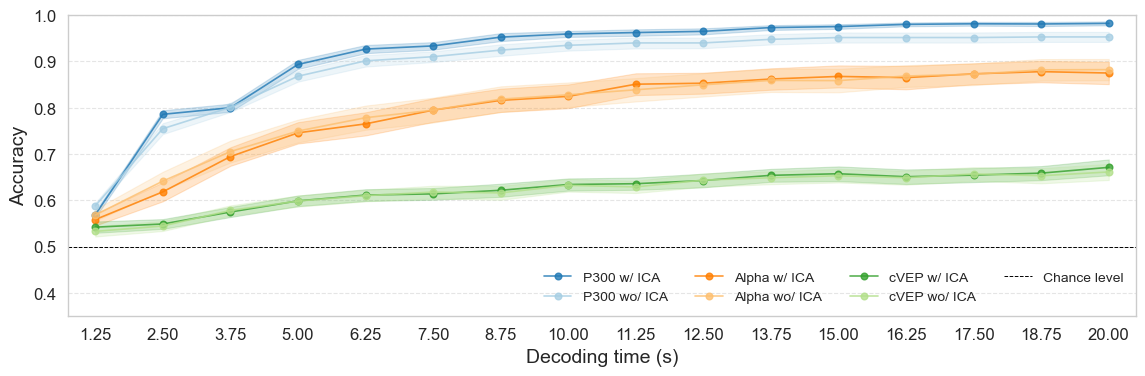

In [192]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Font and style settings
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
})
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

# 2) Prepare your data
isi = 0.250  # seconds per bin
x = np.array(epoch_bins) * isi

# 3) Use the Paired palette (6 colors = 3 subtle pairs)
full   = sns.color_palette("Paired", 12)
blue   = full[0:2][::-1]
orange = full[6:8][::-1]
green  = full[2:4][::-1]

palette = blue + orange + green

# 4) Create the figure
fig, ax = plt.subplots(figsize=(11.69, 4))

# 5) Plot each of your 6 pipelines with its paired‐shade color
for (label, ds), color in zip(data.items(), palette):
    ax.plot(x, ds['mean'],
            marker=ds.get('marker', 'o'),
            linestyle=ds.get('linestyle', '-'),
            color=color,
            alpha = 0.8,
            label=label)
    ax.fill_between(x,
                    ds['mean'] - ds['se'],
                    ds['mean'] + ds['se'],
                    color=color,
                    alpha=0.2)

# 6) Add chance‐level, labels, legend, grids
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7, label='Chance level')
ax.set_xlabel("Decoding time (s)", fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0.35, 1.0)
ax.set_xticks(x)
ax.tick_params(labelsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower right', ncol=4, fontsize=10, frameon=False)

ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(False)
plt.tight_layout()

# 7) Save & show
file_name = os.path.join(fig_dir, 'decoding_arena.pdf')
plt.savefig(file_name, format="pdf", dpi=300, bbox_inches="tight")
plt.show()


In [186]:
##  reporting threshold crossings

In [187]:
import pandas as pd
time_s = np.array([2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0])
thresholds=(0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95)

    
full_n = len(next(iter(data.values()))['mean'])
n = len(time_s)

# Determine subsample indices if needed
if full_n == n:
    idxs = np.arange(n)
elif full_n % n == 0:
    step = full_n // n
    # align by picking the last bin in each group of size 'step'
    idxs = (step - 1) + np.arange(n) * step
else:
    raise ValueError(f"Cannot align data of length {full_n} to {n} time points")

# Build accuracy-by-time table
acc_df = pd.DataFrame(
    {pipeline: infos['mean'][idxs] * 100 for pipeline, infos in data.items()},
    index=time_s
).astype(float).round(1)
acc_df.index.name = 'Time'
acc_df.to_latex(float_format="%.1f")

# Compute time-to-threshold for each pipeline
records = []
for pipeline, infos in data.items():
    subsamp = infos['mean'][idxs]
    for thr in thresholds:
        # find first subsample crossing threshold
        crossings = np.where(subsamp >= thr)[0]
        t = time_s[crossings[0]] if crossings.size else '/'
        records.append({'Strategy': pipeline, 'Accuracy': thr * 100, 'Time': t})

time_df = (
    pd.DataFrame(records)
        .pivot(index='Accuracy', columns='Strategy', values='Time')
        .round(1)
)


In [188]:
acc_df

,P300 w/ ICA,P300 wo/ ICA,Alpha w/ ICA,Alpha wo/ ICA,cVEP w/ ICA,cVEP wo/ ICA
Time,,,,,,
2.5,78.6,75.5,61.8,64.1,54.9,54.4
5.0,89.4,86.8,74.6,75.0,59.9,59.8
7.5,93.4,91.0,79.5,79.5,61.4,61.8
10.0,95.9,93.5,82.5,82.8,63.4,63.2
12.5,96.5,94.0,85.3,85.0,64.3,64.4
15.0,97.5,95.2,86.8,85.9,65.7,65.3
17.5,98.1,95.2,87.3,87.2,65.4,65.7
20.0,98.2,95.3,87.5,88.2,67.1,66.1


In [189]:
time_df

Strategy,Alpha w/ ICA,Alpha wo/ ICA,P300 w/ ICA,P300 wo/ ICA,cVEP w/ ICA,cVEP wo/ ICA
Accuracy,,,,,,
60.0,2.5,2.5,2.5,2.5,7.5,7.5
65.0,5.0,5.0,2.5,2.5,15.0,15.0
70.0,5.0,5.0,2.5,2.5,/,/
75.0,7.5,7.5,2.5,2.5,/,/
80.0,10.0,10.0,5.0,5.0,/,/
85.0,12.5,15.0,5.0,5.0,/,/
90.0,/,/,7.5,7.5,/,/
95.0,/,/,10.0,15.0,/,/


In [190]:
# Export LaTeX with blank for NaN
acc_latex = acc_df.to_latex(
    na_rep='', 
    caption="Mean decoding accuracy (\\%) at each time interval", 
    label="tab:accuracy_by_time", 
    float_format="%.1f"
)
time_latex = time_df.to_latex(
    na_rep='', 
    caption="First time (s) to reach each accuracy threshold", 
    label="tab:time_to_threshold", 
    float_format="%.1f"
)

with open(join(manuscript_dir, 'tables', 'accuracy_threshold_table.tex'), 'w') as f:
    f.write(acc_latex)
with open(join(manuscript_dir, 'tables', 'time_threshold_table.tex'), 'w') as f:
    f.write(time_latex)